# Lab 1 — Basic EDA on PM2.5 Dataset

**Course:** Fundamentals of Data Science  
**Topic:** Week 1 – Introduction to Data Science & Basic EDA  
**Dataset:** `pm2.52024.csv`

---
## Lab Objectives
หลังจบ Lab นี้ ผู้เรียนควรจะสามารถ:
1. เข้าใจโครงสร้างชุดข้อมูล PM2.5 เช่น จำนวนแถว–คอลัมน์ ชนิดข้อมูล และคุณภาพข้อมูลเบื้องต้น
2. คำนวณสถิติเชิงพรรณนา (mean, median, min, max) เพื่ออธิบายลักษณะข้อมูลได้
3. ตรวจสอบ missing values และค่าผิดปกติ (outliers) เบื้องต้นได้
4. สร้าง visualization พื้นฐาน เช่น line plot และ histogram เพื่อสำรวจแนวโน้มค่าฝุ่น PM2.5 ได้

---

## A. Introduction

ใน Lab นี้ เราจะใช้ชุดข้อมูล PM2.5 จริงจากจุดตรวจวัดคุณภาพอากาศอัตโนมัติในพื้นที่กรุงเทพมหานครและปริมณฑล เพื่อฝึกทำ **Exploratory Data Analysis (EDA)** ขั้นพื้นฐานบน Google Colab ด้วยภาษา Python และไลบรารี `pandas`.

เป้าหมายของ Lab คือให้ผู้เรียนคุ้นเคยกับขั้นตอนสำคัญของ EDA ได้แก่:
- การโหลดและตรวจสอบโครงสร้างของข้อมูล
- การคำนวณสถิติเบื้องต้น
- การสร้างกราฟพื้นฐานเพื่อสำรวจแนวโน้มและการกระจายตัวของข้อมูล

---

## B. Dataset Description

ชุดข้อมูลที่ใช้ใน Lab นี้คือ **`pm2.52024.csv`** ซึ่งเป็น[ข้อมูลค่าฝุ่นละอองขนาดเล็ก PM2.5 จากจุดตรวจวัดคุณภาพอากาศอัตโนมัติในพื้นที่กรุงเทพมหานครและปริมณฑล ในปี พ.ศ. 2567](https://pcd.gdcatalog.go.th/dataset/air-quality-bangkok-metropolitan-region)

ลักษณะข้อมูล:
- 1 คอลัมน์วันที่: `Date` – ระบุวันที่ที่มีการบันทึกข้อมูล
- หลายคอลัมน์สถานี เช่น `54T`, `50T`, `03T`, `A13`, ... – แต่ละคอลัมน์คือค่าฝุ่น PM2.5 ของสถานีนั้น ๆ (หน่วย: ไมโครกรัมต่อลูกบาศก์เมตร, µg/m³)

ข้อมูลนี้เหมาะสำหรับการฝึกทำความเข้าใจข้อมูลหลายสถานีพร้อมกัน และฝึกเลือกวิเคราะห์เฉพาะสถานีที่สนใจผ่านการตั้งค่าตัวแปร `station`.

---

## C. Load Data

ในส่วนนี้ เราจะเริ่มต้นจากการ import ไลบรารีที่จำเป็น และอัปโหลดไฟล์ `pm2.52024.csv` ขึ้นสู่ Colab จากนั้นจึงอ่านข้อมูลเข้าสู่ `DataFrame` ของ pandas.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


In [2]:
from google.colab import files
uploaded = files.upload()

# หลังจากรันเซลล์นี้ ให้เลือกไฟล์ pm2.52024.csv จากเครื่องของคุณ

Saving pm2.52024.csv to pm2.52024.csv


In [3]:
# อ่านไฟล์ CSV เข้าสู่ DataFrame
df = pd.read_csv('/content/pm2.52024.csv')

# แสดง 5 แถวแรกเพื่อตรวจสอบว่าข้อมูลถูกอ่านเข้ามาถูกต้องหรือไม่
df.head()

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
0,1/1/2024,38.3,29.4,28.2,29.0,24.3,22.0,23.3,34.3,31.4,...,31.6,19.8,23.6,17.0,19.0,19.0,10.6,18.9,22.4,11.6
1,2/1/2024,39.5,29.0,25.8,26.6,27.4,21.4,23.5,36.9,33.1,...,29.9,9.2,19.9,13.3,15.7,18.4,10.2,16.5,14.5,11.5
2,3/1/2024,38.2,28.7,26.3,23.7,25.8,21.4,23.5,35.9,30.3,...,37.2,13.2,22.6,15.5,18.9,19.1,9.2,18.4,14.0,11.3
3,4/1/2024,36.6,36.4,31.1,28.9,29.1,22.9,25.8,37.8,32.1,...,32.4,15.9,22.6,17.2,21.5,21.0,10.2,21.8,18.7,13.1
4,5/1/2024,36.0,32.6,30.1,26.5,25.5,20.6,25.4,35.8,32.5,...,34.1,NaN,23.7,17.7,23.6,22.2,11.7,24.0,20.0,24.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 97 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    366 non-null    object 
 1   02T     366 non-null    float64
 2   05T     351 non-null    float64
 3   10T     355 non-null    float64
 4   11T     321 non-null    float64
 5   12T     345 non-null    float64
 6   59T     366 non-null    float64
 7   61T     321 non-null    float64
 8   03T     356 non-null    float64
 9   50T     365 non-null    float64
 10  52T     360 non-null    float64
 11  53T     365 non-null    float64
 12  54T     366 non-null    float64
 13  08T     363 non-null    float64
 14  16T     354 non-null    float64
 15  17T     359 non-null    float64
 16  18T     355 non-null    float64
 17  19T     357 non-null    float64
 18  13T     362 non-null    float64
 19  22T     366 non-null    float64
 20  14T     366 non-null    float64
 21  27T     361 non-null    float64
 22  20

In [5]:
# แปลงคอลัมน์ Date ให้เป็นชนิดข้อมูล datetime (ถ้ายังไม่ใช่)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df.dtypes

,0
Date,datetime64[ns]
02T,float64
05T,float64
10T,float64
11T,float64
...,...
63T,float64
78T,float64
80T,float64
89T,float64


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## D. Data Understanding

ในส่วนนี้ เราจะสำรวจโครงสร้างของ DataFrame และตรวจสอบคุณภาพข้อมูลเบื้องต้น เช่น จำนวนแถว–คอลัมน์, ชนิดข้อมูล, missing values และ duplicate rows.

In [7]:
# 1. ตรวจสอบจำนวนแถวและคอลัมน์
df.shape # ออกมาเป็น tuple

(366, 97)

In [8]:
# 2. ดูตัวอย่างข้อมูล 5 แถวแรก
df.head()

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
0,2024-01-01,38.3,29.4,28.2,29.0,24.3,22.0,23.3,34.3,31.4,...,31.6,19.8,23.6,17.0,19.0,19.0,10.6,18.9,22.4,11.6
1,2024-01-02,39.5,29.0,25.8,26.6,27.4,21.4,23.5,36.9,33.1,...,29.9,9.2,19.9,13.3,15.7,18.4,10.2,16.5,14.5,11.5
2,2024-01-03,38.2,28.7,26.3,23.7,25.8,21.4,23.5,35.9,30.3,...,37.2,13.2,22.6,15.5,18.9,19.1,9.2,18.4,14.0,11.3
3,2024-01-04,36.6,36.4,31.1,28.9,29.1,22.9,25.8,37.8,32.1,...,32.4,15.9,22.6,17.2,21.5,21.0,10.2,21.8,18.7,13.1
4,2024-01-05,36.0,32.6,30.1,26.5,25.5,20.6,25.4,35.8,32.5,...,34.1,NaN,23.7,17.7,23.6,22.2,11.7,24.0,20.0,24.9


In [9]:
# 3. ดูตัวอย่างข้อมูล 5 แถวสุดท้าย
df.tail()

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
361,2024-12-27,47.4,35.4,35.8,35.4,35.9,23.2,34.6,43.9,41.6,...,51.2,12.1,12.4,12.0,12.8,13.0,12.3,12.3,12.4,12.2
362,2024-12-28,28.2,22.9,22.5,22.8,23.4,17.0,22.6,25.6,28.2,...,37.8,8.5,9.8,9.7,8.6,8.9,8.5,9.5,8.4,7.5
363,2024-12-29,25.8,20.1,20.4,20.6,20.7,17.0,20.1,22.3,23.8,...,24.9,8.8,10.1,10.1,8.9,9.0,8.7,10.1,7.7,7.9
364,2024-12-30,40.0,28.4,28.2,28.4,28.1,26.2,27.1,34.3,33.2,...,37.9,12.9,13.7,14.0,12.2,12.3,12.1,13.7,11.6,11.0
365,2024-12-31,37.1,33.9,32.9,30.0,30.1,21.9,29.5,32.5,34.1,...,35.2,14.4,15.6,15.6,15.1,15.2,14.5,15.4,14.8,13.2


In [10]:
df.sample(7, random_state=150)

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
207,2024-07-26,19.2,17.9,11.7,13.9,11.7,10.8,13.8,18.4,17.1,...,12.3,18.6,20.7,21.9,22.1,22.7,21.9,21.9,19.1,20.7
241,2024-08-29,13.5,13.2,8.7,11.1,11.2,5.8,NaN,13.7,14.0,...,12.9,9.3,10.1,9.9,9.5,9.4,8.8,8.9,9.3,7.1
187,2024-07-06,17.8,15.9,11.2,11.7,12.3,9.6,14.7,16.4,16.9,...,11.7,11.2,12.2,12.2,9.4,9.3,8.4,11.9,11.9,9.1
84,2024-03-25,24.0,25.9,20.0,23.8,20.8,20.2,20.1,25.5,26.9,...,41.3,21.3,23.4,14.9,15.3,16.6,14.8,16.5,13.4,15.6
53,2024-02-23,20.0,16.6,13.7,16.0,16.1,12.3,17.1,21.1,20.2,...,36.9,14.7,24.2,12.6,15.4,17.9,16.4,12.2,9.3,9.8
65,2024-03-06,25.1,23.7,19.6,20.7,20.1,16.2,19.1,23.6,25.6,...,51.1,27.4,31.7,24.7,19.4,19.8,16.5,26.0,21.5,23.1
116,2024-04-26,18.0,19.1,12.9,15.1,12.6,14.3,15.8,17.5,19.8,...,30.1,19.2,21.7,21.7,15.8,15.7,14.7,18.6,14.0,16.7


In [11]:
df.iloc[31:36] # indexloation ใส่index

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
31,2024-02-01,35.9,34.0,37.0,31.0,31.5,24.4,28.8,38.5,34.6,...,57.1,20.8,29.7,19.6,21.7,21.8,10.4,25.8,20.8,14.7
32,2024-02-02,27.8,24.0,23.8,24.3,24.1,19.4,23.8,30.5,27.5,...,51.9,22.3,31.5,21.3,21.7,21.6,10.8,23.7,19.6,NaN
33,2024-02-03,29.1,26.8,24.0,24.0,NaN,19.4,22.4,32.4,28.3,...,49.2,22.9,29.0,17.4,18.8,20.5,9.7,21.0,17.5,15.0
34,2024-02-04,30.5,28.2,26.0,24.0,22.7,21.3,22.7,31.4,29.5,...,43.0,26.0,35.3,19.8,22.1,22.9,13.3,23.7,20.9,14.6
35,2024-02-05,37.6,30.9,31.5,31.6,29.4,26.5,28.9,40.2,35.5,...,55.3,34.0,36.5,25.8,NaN,28.6,15.3,37.8,30.3,19.8


In [12]:
# 4. ตรวจสอบชนิดข้อมูลของแต่ละคอลัมน์
df.dtypes

,0
Date,datetime64[ns]
02T,float64
05T,float64
10T,float64
11T,float64
...,...
63T,float64
78T,float64
80T,float64
89T,float64


In [13]:
# 5. ใช้ df.info() เพื่อดูข้อมูลสรุปของ DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 97 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    366 non-null    datetime64[ns]
 1   02T     366 non-null    float64       
 2   05T     351 non-null    float64       
 3   10T     355 non-null    float64       
 4   11T     321 non-null    float64       
 5   12T     345 non-null    float64       
 6   59T     366 non-null    float64       
 7   61T     321 non-null    float64       
 8   03T     356 non-null    float64       
 9   50T     365 non-null    float64       
 10  52T     360 non-null    float64       
 11  53T     365 non-null    float64       
 12  54T     366 non-null    float64       
 13  08T     363 non-null    float64       
 14  16T     354 non-null    float64       
 15  17T     359 non-null    float64       
 16  18T     355 non-null    float64       
 17  19T     357 non-null    float64       
 18  13T     36

In [14]:
# 6. ตรวจสอบจำนวน missing values ในแต่ละคอลัมน์
df.isnull().sum()

,0
Date,0
02T,0
05T,15
10T,11
11T,45
...,...
63T,68
78T,3
80T,1
89T,0


In [15]:
for i in df.isnull().sum():
  if i > 0:
    print(i)

15
11
45
21
45
10
1
6
1
3
12
7
11
9
4
5
9
25
5
10
12
7
20
3
3
2
2
69
4
12
10
2
5
1
2
2
1
5
4
6
9
3
7
8
14
7
1
3
3
5
5
6
39
1
1
1
3
8
2
1
2
7
5
20
1
2
12
7
1
31
68
3
1
2


In [16]:
# 7. ตรวจสอบจำนวนแถวที่ซ้ำ
df.duplicated().sum() # ถ้าเหมือนทุกcolumn ถึงจะถือว่าซ้ำ

np.int64(0)

**คำถามสำหรับผู้เรียน:**
- จากผลลัพธ์ของ `df.info()` คอลัมน์ใดมี missing values บ้าง และมีจำนวนเท่าใด?
- มีแถวข้อมูลซ้ำหรือไม่? ถ้ามี คิดว่าควรจัดการอย่างไรในขั้นตอนการเตรียมข้อมูล?

## E. Descriptive Statistics

เราจะคำนวณสถิติเชิงพรรณนาเบื้องต้นของข้อมูลเชิงตัวเลข (แต่ละสถานี) เพื่อดูภาพรวมของค่าฝุ่น PM2.5.

In [17]:
# 1. สถิติโดยรวมของทุกคอลัมน์ตัวเลข
df.describe()

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,98T,42T,43T,44T,62T,63T,78T,80T,89T,93T
count,366,366.000000,351.000000,355.000000,321.000000,345.000000,366.000000,321.000000,356.000000,365.000000,...,364.000000,354.000000,359.000000,365.000000,335.000000,298.000000,363.000000,365.000000,366.000000,364.000000
mean,2024-07-01 12:00:00.000000256,25.577869,23.274359,20.043380,21.703427,20.563478,16.410383,21.111526,25.875281,25.523562,...,29.868681,14.295198,17.242340,14.304932,14.230149,15.161074,11.875482,14.911507,13.173224,12.003571
min,2024-01-01 00:00:00,8.700000,7.200000,6.300000,5.800000,6.200000,4.100000,9.000000,10.900000,9.700000,...,9.700000,5.300000,6.200000,6.200000,6.300000,6.300000,6.300000,5.700000,5.000000,5.300000
25%,2024-04-01 06:00:00,16.500000,15.000000,10.900000,12.900000,12.300000,9.400000,13.900000,16.600000,16.900000,...,13.400000,9.600000,10.700000,10.700000,10.200000,11.700000,9.200000,10.200000,9.600000,8.275000
50%,2024-07-01 12:00:00,21.500000,20.100000,17.100000,19.200000,18.100000,14.500000,18.900000,22.400000,23.100000,...,27.950000,12.550000,13.700000,13.200000,13.000000,14.200000,11.300000,13.100000,11.950000,11.250000
75%,2024-09-30 18:00:00,31.475000,28.550000,25.300000,28.700000,25.800000,21.400000,25.600000,32.325000,31.400000,...,42.850000,18.450000,23.800000,17.500000,18.400000,19.250000,13.750000,18.700000,16.400000,14.700000
max,2024-12-31 00:00:00,79.000000,77.500000,76.600000,69.300000,73.400000,53.300000,65.600000,79.000000,74.100000,...,83.800000,34.000000,45.300000,26.400000,25.600000,28.600000,21.900000,37.800000,30.300000,25.100000
std,NaN,12.242691,11.090873,11.772619,10.951062,10.805099,8.978251,9.155942,12.100383,10.983286,...,16.809056,5.793628,8.366436,4.661418,4.742598,4.740778,3.360837,6.292725,4.744721,4.441578


จากตารางด้านบน ให้สังเกตค่า:
- `mean` (ค่าเฉลี่ย)
- `50%` (ค่ามัธยฐาน)
- `min` และ `max`

**คำถามสำหรับผู้เรียน:**
- โดยรวมแล้ว ค่าฝุ่นของสถานีต่าง ๆ มีแนวโน้มอยู่ในช่วงประมาณใด?
- มีสถานีใดที่ `max` สูงผิดปกติเมื่อเทียบกับสถานีอื่นหรือไม่?

## F. Basic Visualization

ในส่วนนี้ เราจะสร้างกราฟพื้นฐานเพื่อสำรวจแนวโน้มและการกระจายตัวของค่าฝุ่น PM2.5 โดยให้ผู้เรียน **เลือกสถานีที่ต้องการวิเคราะห์เอง** ผ่านตัวแปร `station`.

In [18]:
# เลือกสถานีที่ต้องการวิเคราะห์ (แก้ไขชื่อตามคอลัมน์ใน DataFrame)
station = '54T'  # ตัวอย่างชื่อสถานี เช่น '54T', '50T', '03T', 'A13'

# แสดงชื่อคอลัมน์เพื่อตรวจสอบว่าสถานีที่เลือกมีอยู่จริง
df.columns

Index(['Date', '02T', '05T', '10T', '11T', '12T', '59T', '61T', '03T', '50T',
       '52T', '53T', '54T', '08T', '16T', '17T', '18T', '19T', '13T', '22T',
       '14T', '27T', '20T', '81T', '21T', '24T', '25T', '26T', '79T', '84T',
       '85T', '99T', '103T', '104T', '46T', '47T', '72T', '82T', '83T', '88T',
       '90T', '91T', '101T', '102T', '106T', '107T', '108T', '109T', '110T',
       '111T', '112T', '28T', '29T', '30T', '31T', '74T', '32T', '33T', '34T',
       '60T', '71T', '77T', '87T', '100T', '105T', '35T', '36T', '37T', '38T',
       '39T', '40T', '41T', '57T', '73T', '58T', '67T', '75T', '68T', '69T',
       '70T', '76T', '86T', '92T', '94T', '95T', '96T', '97T', '98T', '42T',
       '43T', '44T', '62T', '63T', '78T', '80T', '89T', '93T'],
      dtype='object')

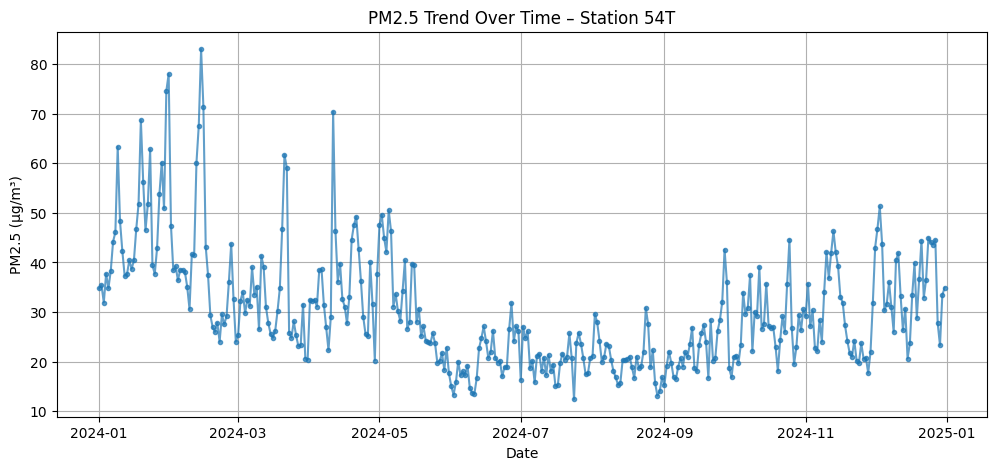

In [19]:
# 1. Line Plot – แนวโน้ม PM2.5 ตามเวลา สำหรับสถานีที่เลือก
plt.figure(figsize=(12,5)) # 12 * 5 นิ้ว เป็น default
plt.plot(df['Date'], df[station], marker='.', linestyle='-', alpha=0.7) # marker คือ ตรงค่านั้นให้เป็นจุด linestyle คือ เส้นเชื่อมระหว่างจุด
plt.title(f'PM2.5 Trend Over Time – Station {station}')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.grid(True)
plt.show()

**คำถามสำหรับผู้เรียน:**
- กราฟเส้นของสถานีนี้มีช่วงที่ค่าฝุ่นสูงผิดปกติหรือไม่? อยู่ในช่วงเวลาใด?
- มีช่วงใดที่ค่าฝุ่นค่อนข้างคงที่หรือไม่?

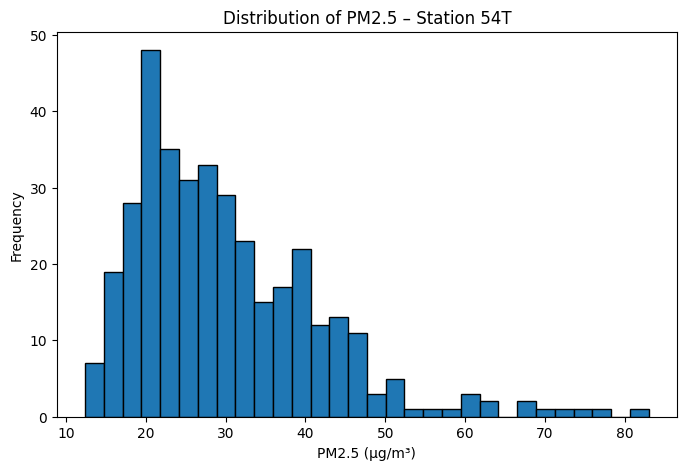

In [20]:
# 2. Histogram – การกระจายตัวของค่า PM2.5 ของสถานีที่เลือก
plt.figure(figsize=(8,5))
plt.hist(df[station].dropna(), bins=30, edgecolor='black')
plt.title(f'Distribution of PM2.5 – Station {station}')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('Frequency')
plt.show()

**คำถามสำหรับผู้เรียน:**
- ค่าฝุ่นของสถานีนี้ส่วนใหญ่อยู่ในช่วงประมาณเท่าใด?
- การกระจายตัวมีแนวโน้มเอียงไปทางซ้ายหรือขวาหรือไม่ (skewed)?

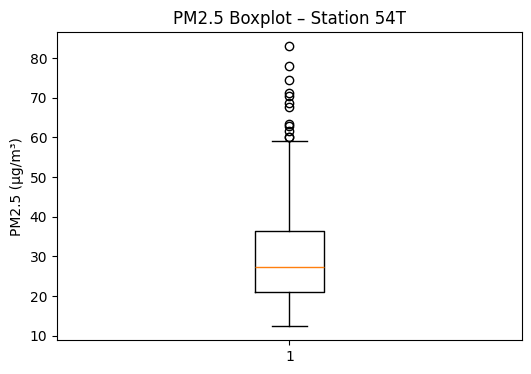

In [21]:
# 3. Boxplot – ตรวจสอบ outliers ของสถานีที่เลือก
plt.figure(figsize=(6,4))
plt.boxplot(df[station].dropna(), vert=True)
plt.title(f'PM2.5 Boxplot – Station {station}')
plt.ylabel('PM2.5 (µg/m³)')
plt.show()

**คำถามสำหรับผู้เรียน:**
- มีจุด outlier หรือค่าที่สูงมากกว่าค่าปกติทั่วไปหรือไม่?
- ถ้ามี outliers จำนวนมาก คุณคิดว่าควรจัดการอย่างไรในขั้นตอนการเตรียมข้อมูลสำหรับโมเดล?

## G. Mini Tasks (Hands-on)

ให้ทำแบบฝึกปฏิบัติต่อไปนี้ โดยสามารถเปลี่ยนค่าตัวแปร `station` เพื่อเลือกสถานีอื่น ๆ มาวิเคราะห์ได้ตามต้องการ.

### Task 1 — หาวันที่ค่าฝุ่นสูงที่สุดของสถานีที่เลือก
ใช้คำสั่ง `idxmax()` เพื่อหาวันที่ค่าฝุ่นสูงที่สุดของสถานีที่เลือก และแสดงแถวนั้นออกมา:

```python
df.loc[df[station].idxmax()]
```

**คำถาม:** วันที่ค่าฝุ่นสูงที่สุดคือวันใด และค่าฝุ่นเท่าใด?

In [27]:
station = "10T"
df.loc[df[station].idxmax()]

,44
Date,2024-02-14 00:00:00
02T,79.0
05T,77.5
10T,76.6
11T,69.3
...,...
63T,21.6
78T,16.5
80T,23.1
89T,27.8


**ตอบ** วันที่ค่าฝุ่นสูงที่สุด คือวันที่ 2024-02-14

### Task 2 — คำนวณสถิติเชิงพรรณนาเฉพาะสถานีที่เลือก
ให้ใช้คำสั่ง:

```python
df[station].describe()
```

แล้วตอบคำถาม:
- ค่า mean และ median ต่างกันมากหรือไม่?
- จากค่า min และ max คุณคิดว่าสถานีนี้มีช่วงค่าฝุ่นกว้างหรือแคบ?

In [28]:
station = "10T"
df[station].describe()

,10T
count,355.000000
mean,20.043380
std,11.772619
min,6.300000
25%,10.900000
50%,17.100000
75%,25.300000
max,76.600000


**ตอบ** mean 20.04 และ median 17.10 ต่างกัน 2.94 ต่างกันเล็กน้อยถึงปานกลาง

**ตอบ** min 6.3 และ max 76.6 มีช่วงค่าฝุ่นกว้าง

### Task 3 — เปรียบเทียบ 2 สถานี
เลือกสถานีใหม่เพิ่มอีก 1 สถานี แล้วเปรียบเทียบกับสถานีเดิม:

```python
station1 = '54T'
station2 = '03T'

df[[station1, station2]].describe()
```

**คำถาม:**
- สถานีใดมีค่า mean สูงกว่า?
- สถานีใดมีค่า std สูงกว่า (ผันผวนมากกว่า)?

In [29]:
station1 = "10T"
station2 = "50T"

df[[station1, station2]].describe()

,10T,50T
count,355.000000,365.000000
mean,20.043380,25.523562
std,11.772619,10.983286
min,6.300000,9.700000
25%,10.900000,16.900000
50%,17.100000,23.100000
75%,25.300000,31.400000
max,76.600000,74.100000


**ตอบ** สถานี 50T มีค่า mean สูงกว่า

**ตอบ** สถานี 10T มีค่า std สูงกว่า

### Task 4 — Line Plot สองสถานีพร้อมกัน
สร้างกราฟเส้นของ 2 สถานีในกราฟเดียว แล้วเปรียบเทียบแนวโน้ม:

```python
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df[station1], label=station1)
plt.plot(df['Date'], df[station2], label=station2)
plt.title('PM2.5 Trend Comparison')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True)
plt.show()
```

**คำถาม:** สถานีใดมีแนวโน้มค่าฝุ่นสูงกว่าโดยรวม และมีช่วงเวลาที่สองสถานีมี pattern คล้ายกันหรือไม่?

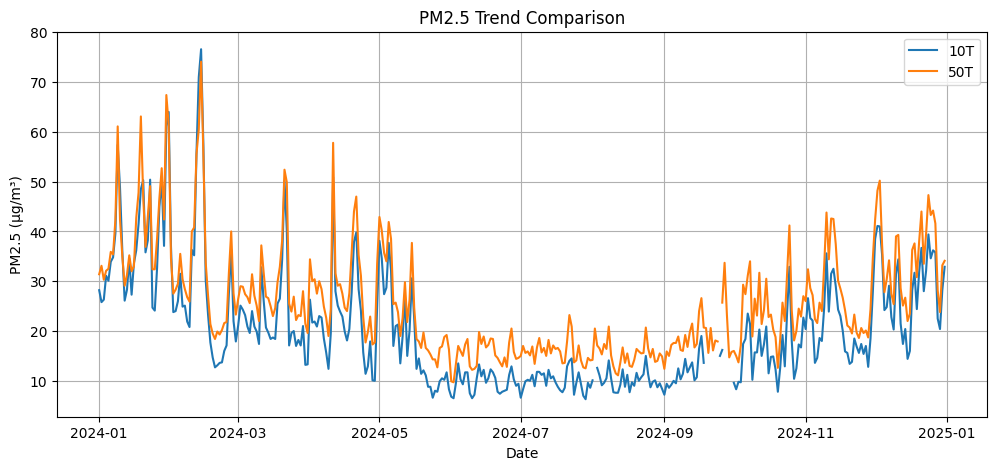

In [30]:
station1 = "10T"
station2 = "50T"

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df[station1], label=station1)
plt.plot(df['Date'], df[station2], label=station2)
plt.title('PM2.5 Trend Comparison')
plt.xlabel('Date')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True)
plt.show()

**ตอบ** สถานี 50T แนวโน้มค่าฝุ่นสูงกว่า และดูมี pattern ไปในทิศทางเดียวกัน

---



## H. Summary

ตอบคำถามสรุปต่อไปนี้โดยอิงจากการวิเคราะห์ของคุณใน Lab นี้ (ทำใน Google Form):

1. แนวโน้มของค่าฝุ่น PM2.5 ของสถานีที่คุณเลือกเป็นอย่างไร (เช่น มีช่วงพุ่งสูง หรือช่วงค่าคงที่)?

2. ค่าฝุ่นส่วนใหญ่อยู่ในช่วงประมาณเท่าใด (ดูจาก histogram และค่า median)?

3. มี outliers หรือค่าที่สูงผิดปกติหรือไม่? คุณคิดว่า outliers เหล่านี้มีสาเหตุจากอะไรได้บ้าง?

4. เมื่อเปรียบเทียบ 2 สถานี (Task 3–4) คุณพบความแตกต่างสำคัญอะไรบ้างในด้านระดับค่าฝุ่นและความผันผวน?

5. จากมุมมองของคุณ สิ่งสำคัญที่สุด 1–2 ข้อที่คุณได้เรียนรู้จาก Lab 1 นี้คืออะไร?